Conclusion: Nothing can be said for sure

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [13]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [14]:
df = pd.read_csv("../../data/preprocessed/wastewater.csv")
df.Date = pd.to_datetime(df.Date)

In [15]:
df.head()

,Sampling_Area,Date,Avg_FlowRate,COVID_N1,COVID_N2,PMMoV,Temperature,Bemerkung,Project,bestimmungsgrenze,precipitation_event,flow_normalized_COVID_N1,flow_normalized_COVID_N2,PMMoV_normalized_COVID_N1,PMMoV_normalized_COVID_N2
0,South,2022-02-28,440.960648,5754.242558,3463.697591,5.426348e+06,11.80,3.46369759101506,ESI_CorA,False,dry,8083.334228,4865.666507,40943.383562,24645.380791
1,North,2022-03-02,454.606481,69802.087396,32133.554283,5.212840e+07,12.00,NaN,ESI_CorA,False,dry,101089.621573,46536.843860,51700.801303,23800.584869
2,South,2022-03-02,454.606481,11913.284794,8173.140016,7.364685e+06,15.60,NaN,ESI_CorA,False,dry,17253.201107,11836.603490,62456.923001,42848.734456
3,North,2022-03-07,446.041667,71179.149700,22482.965460,4.268556e+07,13.05,NaN,ESI_CorA,False,dry,101141.819665,31947.108776,64383.569621,20336.483058
4,South,2022-03-07,446.041667,17522.583462,10906.017579,8.340562e+06,14.38,NaN,ESI_CorA,False,dry,24898.667434,15496.876092,81115.907111,50486.362972


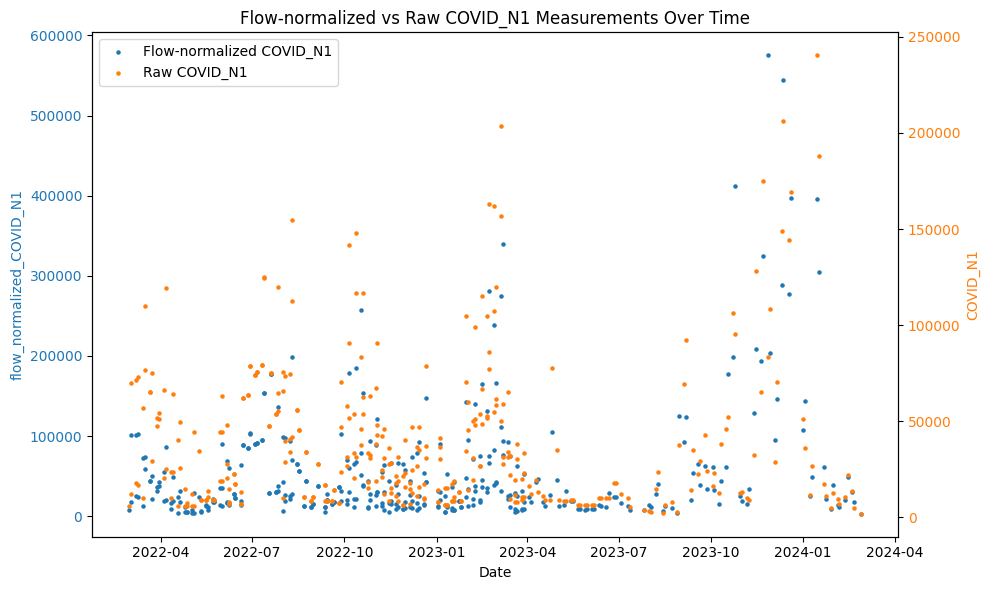

In [41]:
import matplotlib.pyplot as plt

# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot flow_normalized_COVID_N1 on primary y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('flow_normalized_COVID_N1', color=color1)
ax1.scatter(df['Date'], df['flow_normalized_COVID_N1'], color=color1, label='Flow-normalized COVID_N1', s=5)
ax1.tick_params(axis='y', labelcolor=color1)

# Create secondary y-axis
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('COVID_N1', color=color2)
ax2.scatter(df['Date'], df['COVID_N1'], color=color2, label='Raw COVID_N1', s=5)
ax2.tick_params(axis='y', labelcolor=color2)

# Add a title and layout
plt.title('Flow-normalized vs Raw COVID_N1 Measurements Over Time')
fig.tight_layout()

# Optional: Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()


In [22]:
# Define the list of COVID measurement columns and the grouping variable
covid_cols = ['flow_normalized_COVID_N1', 'flow_normalized_COVID_N2', 
              "COVID_N1", "COVID_N2", 'PMMoV_normalized_COVID_N1', 'PMMoV_normalized_COVID_N2']
group_col = "precipitation_event"

# Dictionary to hold results
results = {}

for col in covid_cols:
    # Drop missing values for current variable
    data = df.loc[df.Project=="ESI_CorA",[group_col, col]].dropna()

    # Run one-way ANOVA
    model = ols(f'{col} ~ C({group_col})', data=data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    # Perform Tukey HSD test for post-hoc pairwise comparisons
    tukey = pairwise_tukeyhsd(endog=data[col],
                              groups=data[group_col],
                              alpha=0.05)

    # Store results
    results[col] = {
        'anova_table': anova_table,
        'tukey_summary': tukey.summary()
    }

# Print results
for col, res in results.items():
    print(f"\n=== {col} ===")
    print("\nANOVA Results:")
    print(res['anova_table'])
    print("\nTukey HSD Post-Hoc Test:")
    print(res['tukey_summary'])



=== flow_normalized_COVID_N1 ===

ANOVA Results:
                              sum_sq     df         F    PR(>F)
C(precipitation_event)  1.510472e+09    2.0  0.989227  0.373742
Residual                1.473480e+11  193.0       NaN       NaN

Tukey HSD Post-Hoc Test:
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
  group1     group2    meandiff  p-adj     lower      upper    reject
---------------------------------------------------------------------
       dry heavy_rain 22583.7727 0.3411 -15424.4768 60592.0222  False
       dry light_rain  -199.4853 0.9994 -14981.4167 14582.4462  False
heavy_rain light_rain -22783.258  0.375 -62949.3855 17382.8696  False
---------------------------------------------------------------------

=== flow_normalized_COVID_N2 ===

ANOVA Results:
                              sum_sq     df        F  PR(>F)
C(precipitation_event)  7.222866e+09    2.0  9.66059  0.0001
Residual                7.214948e+10  193.0      NaN     NaN

Tukey HS

In [34]:
# Define the list of COVID measurement columns and the grouping variable
covid_cols = ['flow_normalized_COVID_N1', 'flow_normalized_COVID_N2', 
              "COVID_N1", "COVID_N2", 'PMMoV_normalized_COVID_N1', 'PMMoV_normalized_COVID_N2']
group_col = "precipitation_event"

# Dictionary to hold results
results = {}

for col in covid_cols:
    # Drop missing values for current variable
    data = df[[group_col, col]].dropna()

    # Run one-way ANOVA
    model = ols(f'{col} ~ C({group_col})', data=data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    print(f"\n=== {col} ===")
    print("ANOVA Results:")
    print(f"H0: means do not differ, p-value: {anova_table.iloc[0,3].round(3)}, reject H0: {anova_table.iloc[0,3] < 0.05}")



=== flow_normalized_COVID_N1 ===
ANOVA Results:
H0: means do not differ, p-value: 0.0, reject H0: True

=== flow_normalized_COVID_N2 ===
ANOVA Results:
H0: means do not differ, p-value: 0.0, reject H0: True

=== COVID_N1 ===
ANOVA Results:
H0: means do not differ, p-value: 0.179, reject H0: False

=== COVID_N2 ===
ANOVA Results:
H0: means do not differ, p-value: 0.136, reject H0: False

=== PMMoV_normalized_COVID_N1 ===
ANOVA Results:
H0: means do not differ, p-value: 0.024, reject H0: True

=== PMMoV_normalized_COVID_N2 ===
ANOVA Results:
H0: means do not differ, p-value: 0.019, reject H0: True


In [33]:
anova_table

,sum_sq,df,F,PR(>F)
C(precipitation_event),1.898801e+11,2.0,18.563652,2.099412e-08
Residual,1.866718e+12,365.0,NaN,NaN


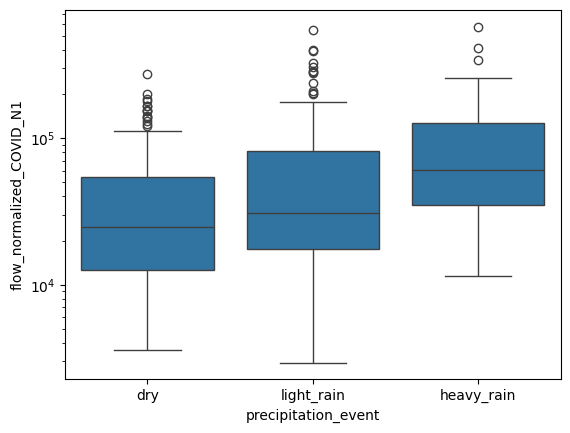

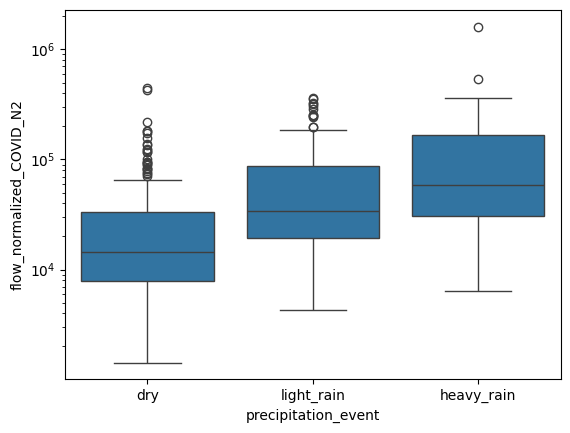

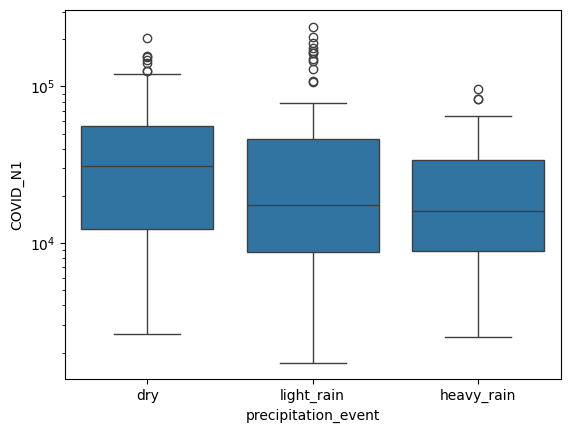

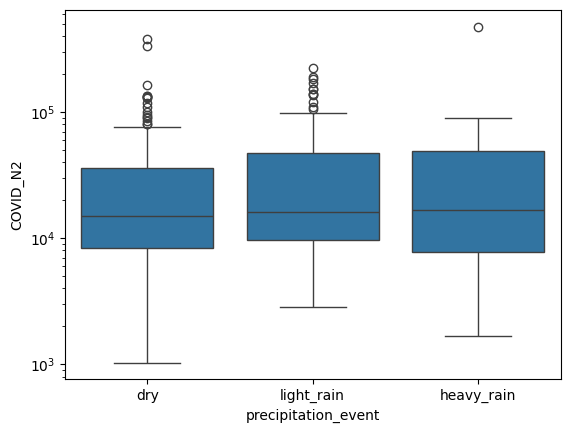

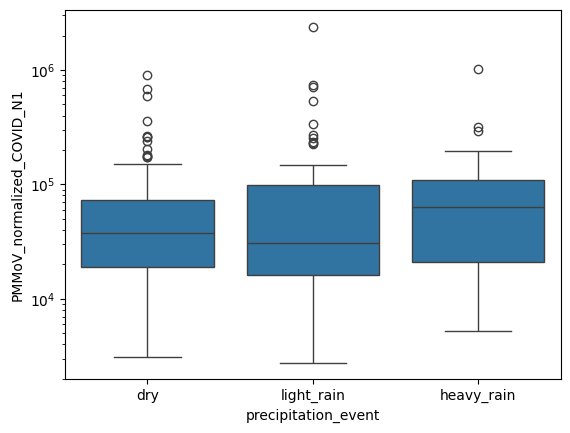

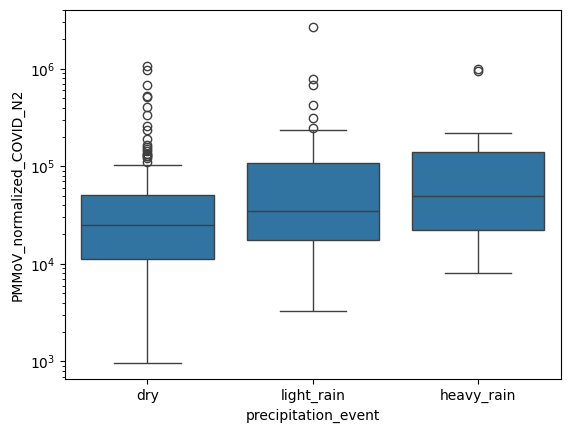

In [43]:
for col in covid_cols:
    sns.boxplot(data=df, x="precipitation_event", y=col)
    plt.yscale("log")  # Set y-axis to log scale
    plt.show()